# Chapter 07 딥러닝을 시작합니다
## 07-1 인공 신경망
### 패션 MNIST

> MNIST가 뭐죠?
> * 머신러닝과 딥러닝을 처음 배울 때 많이 사용하는 데이터셋이 있습니다. 머신러닝에서는 붓꽃 데이터셋이 유명하죠. 딥러닝에서는 MNIST 데이터셋이 유명합니다. 이 데이터는 손으로 쓴 0~9까지의 숫자로 이루어져 있습니다. MNIST와 크기, 개수가 동일하지만 숫자 대션 패션 아이템으로 이루어진 데이터가 바로 패션 MNIST입니다.

* 패션 MNIST 데이터는 워낙 유명하기 때문에 많은 딥러닝 라이브러리에서 이 데이터를 가져올 수 있는 도구를 제공합니다. 여기서는 텐서플로TensorFlow를 사용해 이 데이터를 불러오겠습니다.

In [1]:
from tensorflow import keras
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [2]:
print(train_input.shape, train_target.shape)

(60000, 28, 28) (60000,)


* 훈련 데이터는 60,000개의 이미지로 이루어져 있음. 각 이미지는 28 $\times$ 28 크기. 타깃도 60,000개의 원소가 있는 1차원 배열.

In [3]:
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


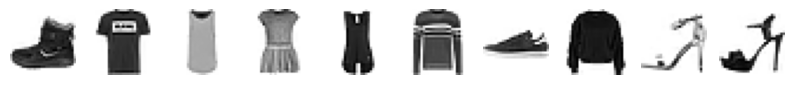

In [4]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 10, figsize=(10,10))
for i in range(10):
  axs[i].imshow(train_input[i], cmap='gray_r')
  axs[i].axis('off')
plt.show()

In [7]:
print([int(train_target[i]) for i in range(10)])

[9, 0, 0, 3, 0, 2, 7, 2, 5, 5]


* 패션 MNIST의 타깃은 0~9까지의 숫자 레이블로 구성됨.
* 패션 MNIST에 포함된 10개 레이블의 의미는 다음과 같음.
| 레이블    | 0   | 1  | 2   | 3   | 4  | 5  | 6  | 7    | 8  | 9     |
| ------ | --- | -- | --- | --- | -- | -- | -- | ---- | -- | ----- |
| 패션 아이템 | 티셔츠 | 바지 | 스웨터 | 드레스 | 코트 | 샌달 | 셔츠 | 스니커즈 | 가방 | 앵클 부츠 |

In [8]:
import numpy as np
print(np.unique(train_target, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


* 0~9까지 레이블마다 정확히 6,000개의 샘플이 들어 있는 것을 볼 수 있음.

### 로지스틱 회귀로 패션 아이템 분류하기
* 이 훈련 샘플은 60,000개나 되기 때문에 전체 데이터를 한꺼번에 사용하여 모델을 훈련하는 것보다 샘플을 하나씩 꺼내서 모델을 훈련하는 방법이 더 효율적으로 보임. -> 이런 상황에 잘 맞는 방법이 확률적 경사 하강법.
> 넘파이 배열의 바이트 크기를 알 수 있나요?
> * 넘파이 배열의 nbytes 속성에 실제 해당 배열이 차지하는 바이트 용량이 저장되어 있음.
* 4장에서 SGDClassifier를 사용할 때 표준화 전처리된 데이터를 사용했음. -> 확률적 경사 하강법은 여러 특성 중 기울기가 가장 가파른 방향을 따라 이동. 만약 특성마다 값의 범위가 많이 다르면 올바르게 손실 함수의 경사를 내려올 수 없음. 패션 MNIST의 경우 각 픽셀은 0\~255 사이의 정숫값을 가짐. 이런 이미지의 경우 보통 255로 나누어 0\~1 사이의 값으로 정규화. 이는 표준화는 아니지만 양수 값으로 이루어진 이미지를 전처리할 때 널리 사용하는 방법.
* 6장에서 했듯이 ```reshape()``` 메서드를 사용해 2차원 배열인 각 샘플을 1차원 배열로 펼침. 4장에서 보았듯이 SGDClassifier는 2차원 입력을 다루지 못하기 때문에 각 샘플을 1차원 배열로 만들어야 함.

In [9]:
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28*28) # 첫 번째 차원(샘플 개수)은 변하지 않고 원본 데이터의 두 번째, 세 번째 차원이 1차원으로 합쳐짐.

In [10]:
print(train_scaled.shape)

(60000, 784)


In [12]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier
sc = SGDClassifier(loss='log_loss', max_iter=5, random_state=42)
scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1)
print(np.mean(scores['test_score']))

0.8194166666666666


* 반복 횟수를 늘려도 성능이 크게 향상되지는 않음.

### 인공 신경망
* 가장 기본적인 인공 신경망은 확률적 경사 하강법을 사용하는 로지스틱 회귀와 같음.
* 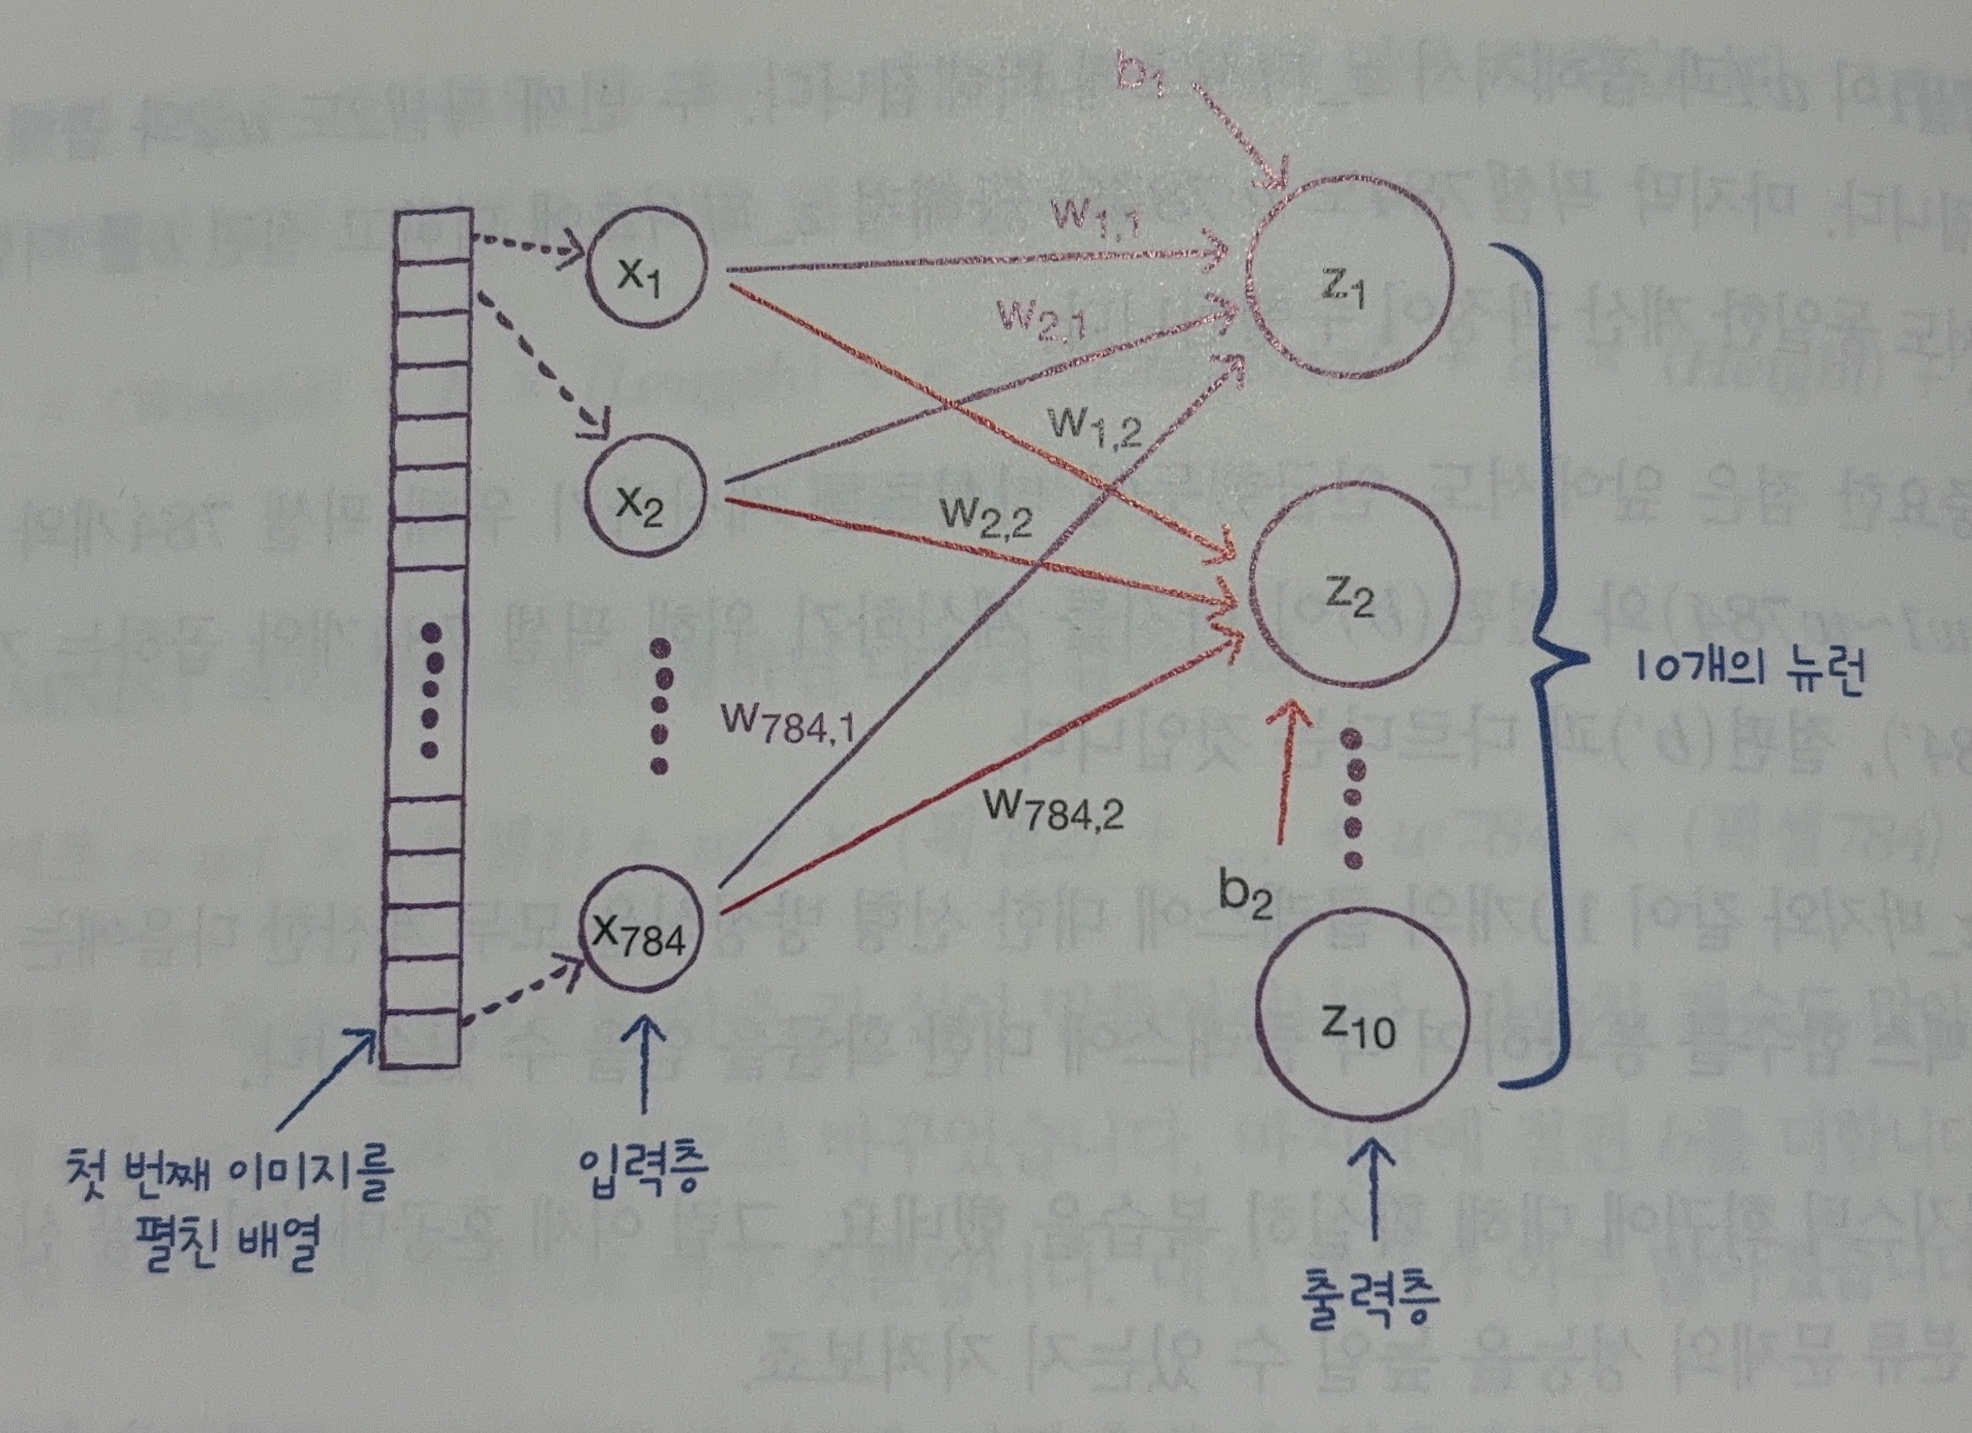

* 클래스가 총 10개이므로 $z_{10}$까지 계산. $z_{1}$~$z_{10}$을 계산하고 이를 바탕으로 클래스를 예측하기 때문에 신경망의 최종 값을 만든다는 의미에서 **출력층output layer**이라고 부름.
* 인공 신경망에서는 $z$값을 계산하는 단위를 **뉴런neuron**이라고 부름.
* 이제는 뉴런이란 표현 대신에 **유닛unit**이라고 부르는 사람이 더 많아지고 있음.
* 인공 신경망은 $x_{1}$~$x_{784}$까지를 **입력층input layer**이라고 부름. 즉 입력층은 픽셀값 자체이고 특별한 계산을 수행하지 않음.
* 인공 신경망은 1943년 워런 매컬러Warren McCulloch와 월터 피츠Walter Pitts가 제안한 뉴런 모델로 거슬러 올라감. -> **매컬러-피츠 뉴런**
* 생물학적 뉴런은 수상 돌기로부터 신호를 받아 세포체에 모음. 신호가 어떤 임곗값에 도달하면 축삭 돌기를 통하여 다른 세포에 신호를 전달.
* 인공 신경망은 정말 우리의 뇌에 있는 뉴런과 같지 않음.
* 인공 신경망은 기존의 머신러닝 알고리즘이 잘 해결하지 못했던 문제에서 높은 성능을 발휘하는 새로운 종류의 머신러닝 알고리즘일 뿐.
> 그럼 딥러닝은 무엇인가요?
> * 딥러닝은 인공 신경망과 거의 동의어로 사용되는 경우가 많음. 혹은 심층 신경망(deep neural network, DNN)을 딥러닝이라고 부름.

#### 텐서플로와 케라스
* 텐서플로는 구글이 2015년 11월 오픈소스로 공개한 딥러닝 라이브러리. 이때를 기점으로 딥러닝에 대한 개발자의 관심이 늘어났고, 2016년 3월 알파고가 이세돌 9단을 이겨 대중에 알려지면서 그야말로 폭발적으로 인기가 높아졌음.
* 텐서플로는 그 후 많은 발전을 거듭하면서 2019년 9월 2.0 버전이 릴리스되었음.
* 텐서플로에는 저수준 API와 고수준 API가 있음. 바로 **케라스Keras**가 텐서플로의 고수준 API. 케라스는 2015년 3월 프랑소와 숄레François Chollet가 만든 딥러닝 라이브러리.
* 딥러닝 라이브러리가 다른 머신러닝 라이브러리와 다른 점 중 하나는 그래픽 처리 장치인 GPU를 사용하여 인공 신경망을 훈련한다는 것. GPU는 벡터와 행렬 연산에 매우 최적화되어 있기 때문에 곱셈과 덧셈이 많이 수행되는 인공 신경망에 큰 도움이 됨.
> 그럼 이 장의 예제를 실행할 때 GPU를 사용해야 하나요?
> * GPU를 사용하면 텐서플로로 만든 딥러닝 모델을 훨씬 빠르게 훈련시킬 수 있음.
> * 다행히 코랩에서 무료로 GPU를 사용할 수 있음.
* 케라스 라이브러리는 직접 GPU 연산을 수행하지 않음. 대신 GPU 연산을 수행하는 다른 라이브러리를 백엔드backend로 사용. 예를 들면 텐서플로가 케라스의 백엔드 중 하나. 이외에도 씨아노, CNTK와 같은 여러 딥러닝 라이브러리를 케라스 백엔드로 사용할 수 있음. 이런 케라스를 멀티-백엔드 케라스라고 부름. 케라스 API만 익히면 다양한 딥러닝 라이브러리를 입맛대로 골라서 쓸 수 있는 셈. 이를 위해 케라스는 직관적이고 사용하기 편한 고수준 API를 제공.
* 프랑소와가 구글에 합류한 뒤 텐서플로 라이브러리에 케라스 API가 내장되었음. 텐서플로 2.0부터는 케라스 API를 남기고 나머지 고수준 API를 모두 정리했고, 케라스는 텐서플로의 핵심 API가 되었음. 다양한 백엔드를 지원했던 멀티-백엔드 케라스는 2.3.1 버전 이후로 더 이상 개발되지 않음. 이제는 케라스와 텐서플로가 거의 동의어가 된 셈.

### 인공 신경망으로 모델 만들기
* 로지스틱 회귀에서는 교차 검증을 사용해 모델을 평가했지만, 인공 신경망에서는 교차 검증을 잘 사용하지 않고 검증 세트를 별도로 덜어내어 사용.
* 이렇게 하는 이유는 1) 딥러닝 분야의 데이터셋은 충분히 크기 때문에 검증 점수가 안정적이고, 2) 교차 검증을 수행하기에는 훈련 시간이 너무 오래 걸리기 때문.

In [13]:
from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [14]:
print(train_scaled.shape, train_target.shape)

(48000, 784) (48000,)


In [15]:
print(val_scaled.shape, val_target.shape)

(12000, 784) (12000,)


* 케라스의 레이어(keras.layers) 패키지 안에는 다양한 층이 준비되어 있음. 가장 기본이 되는 층은 **밀집층dense layer**.
* 784 $\times$ 10=7,840개의 연결된 선이 있음. 빽빽함. -> 밀집층!
* 이런 층을 양쪽의 뉴런이 모두 연결하고 있기 때문에 **완전 연결층fully connected layer**이라고도 부름.

In [20]:
dense = keras.layers.Dense(
    10, # 뉴런 개수
    activation='softmax', # 뉴런의 출력에 적용할 함수(만약 2개의 클래스를 분류하는 이진 분류라면 시그모이드 함수를 사용.)
    input_shape=(784,) # 입력의 크기(10개의 뉴런이 각각 몇 개의 입력을 받는지 튜플로 지정)
)

In [26]:
model = keras.Sequential([dense])

* 소프트맥스와 같이 뉴런의 선형 방정식 계산 결과에 적용되는 함수를 **활성화 함수activation function**이라고 부름.

> 소프트맥스 함수는 별도의 층인가요?
> * 시그모이드 함수나 소프트맥스와 같은 활성화 함수는 뉴런의 출력에 바로 적용되기 때문에 보통 층의 일부로 나타냄. 하지만 종종 "소프트맥스 층을 적용했어"와 같이 따로 부르는 경우도 많음. 가중치와 절편으로 선형 계산을 수행하는 층을 좁은 개념의 신경망 층으로 생각한다면 소프트맥스 층은 넓은 의미의 층이라 볼 수 있음.

### 인공 신경망으로 패션 아이템 분류하기
* 케라스 모델은 훈련하기 전에 설정 단계가 있음. 이런 설정을 model 객체의 ```compile()``` 메서드에서 수행. 꼭 지정해야 할 것은 손실 함수의 종류. 그다음 훈련 과정에서 계산하고 싶은 측정값을 지정.

In [27]:
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

* 다중 분류에서는 크로스 엔트로피 손실 함수를 사용. 케라스에서는 이 두 손실 함수를 각각 'binary_crossentropy', 'categorical_crossentropy'로 나누어 부름.
  * 이진 분류: loss='binary_crossentropy'
  * 다중 분류: loss='categorical_crossentropy'
* 이진 분류에서는 출력층의 뉴런이 하나. 이 뉴런이 출력하는 확률값 $a$(시그모이드 함수의 출력값)를 사용해 양성 클래스와 음성 클래스에 대한 크로스 엔트로피를 계산.
이진 분류의 출력 뉴런은 오직 양성 클래스에 대한 확률($a$)만 출력하기 때문에 음성 클래스에 대한 확률은 간단히 $1-a$로 구할 수 있음. 역시 이진 분류의 타깃값은 양성 샘플일 경우에는 1, 음성 샘플일 경우에는 0으로 되어 있음. 0을 곱하면 어떤 계산이든지 모두 0이 되기 때문에 특별히 음성 샘플일 경우 1로 바꾸어(1-타깃값) 계산합니다. 이렇게 하면 하나의 뉴런만으로 양성과 음성 클래스에 대한 크로스 엔트로피 손실을 모두 계산할 수 있음.
* 그럼 패션 MNIST 데이터셋과 같이 다중 분류일 경우 어떻게 계산할 수 있을까? -> 출력층은 10개의 뉴런이 있고 10개의 클래스에 대한 확률을 출력. 첫 번째 뉴런은 티셔츠일 확률이고 두 번째 뉴런은 바지일 확률을 출력. 이진 분류와 달리 각 클래스에 대한 확률이 모두 출력되기 때문에 타깃에 해당하는 확률만 남겨 놓기 위해서 나머지 확률에는 모두 0을 곱함.
* 결국 신경망은 티셔츠 샘플에서 손실을 낮추려면 첫 번째 뉴런의 활성화 출력 $a_{1}$의 값을 가능한 1에 가깝게 만들어야 함. 바로 이것이 크로스 엔트로피 손실 함수가 신경망에 원한느 바!
* 두 번째 뉴런의 활성화 출력인 $a_{2}$만 남기려면 두 번째 원소만 1이고 나머지는 모두 0으로 타깃값을 준비하면 됨. 바지 샘플을 정확하게 분류하려면 신경망이 $a_{2}$의 출력을 가능한 한 높여야 함. -> 타깃값을 해당 클래스만 1이고 나머지는 모두 0인 배열로 만드는 것을 **원-핫 인코딩one-hot encoding**이라고 부름.
* 다중 분류에서 크로스 엔트로피 손실 함수를 사용하려면 0, 1, 2와 같이 정수로 된 타깃값을 원-핫 인코딩으로 변환해야 함. -> 그런데 패션 MNIST 데이터의 타깃값은? 모두 정수. 하지만 텐서플로에서는 정수로 된 타깃값을 원-핫 인코딩으로 바꾸지 않고 그냥 사용할 수 있음. 정수로 된 타깃값을 사용해 크로스 엔트로피 손실을 계산하는 것이 바로 'sparse_categorical_crossentropy'.
* 타깃값을 원-핫 인코딩으로 준비했다면 ```compile()``` 메서드에 손실 함수를 loss='categorical_crossentropy'로 지정.
* 케라스는 모델이 훈련할 때 기본으로 에포크마다 손실 값을 출력해 줌. 손실이 줄어든느 것을 보고 훈련이 잘되었다는 것을 알 수 있지만 정확도를 함께 출력하기 위해 metrics 매개변수에 정확도 지표를 의미하는 'accuracy'를 지정.

In [28]:
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7929 - loss: 0.6089
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8392 - loss: 0.4751
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8464 - loss: 0.4506
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8512 - loss: 0.4383
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8551 - loss: 0.4297


* 케라스는 친절하게 에포크마다 걸린 시간과 손실(loss), 정확도(accuracy)를 출력해 줌.

In [29]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8481 - loss: 0.4561


[0.45611831545829773, 0.8480833172798157]

* ```evaluate()``` 메서드도 ```fit()``` 메서드와 비슷한 출력을 보여줌. 검증 세트의 점수는 훈련 세트의 점수보다 조금 낮은 것이 일반적.